# 01 — Discovery Notebook
## Chess Suspicious Play Detection Dataset
**Machine Learning — Phase 1 | ENSA Tétouan 2025/2026**

---
## 0. Imports

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


---
## 1. Load the Dataset

In [19]:
df = pd.read_csv('./data/dataset.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded: 12180 rows, 16 columns


---
## 2. First Look

In [20]:
df.head(10)

,player_rating,opponent_rating,rating_diff,player_acpl,expected_acpl,acpl_gap,num_moves,avg_time_per_move,performance_rating,time_control_seconds,time_control,game_result,opening_eco,opening_family,color_played,is_suspicious
0,1178,1173,5,58,100,-42,30,4.79,1578,180,blitz,win,C44,C,white,1
1,1173,1178,5,91,100,-9,30,3.96,773,180,blitz,loss,C44,C,black,0
2,1194,1280,86,47,100,-53,36,2.72,794,180,blitz,loss,C01,C,white,1
3,1280,1194,86,23,90,-67,36,2.77,1680,180,blitz,win,C01,C,black,1
4,1276,1203,73,17,90,-73,29,3.43,1676,180,blitz,win,C57,C,white,1
5,1203,1276,73,48,90,-42,29,2.28,803,180,blitz,loss,C57,C,black,1
6,1288,1200,88,130,90,40,38,3.03,1688,180,blitz,win,C25,C,white,0
7,1200,1288,88,152,90,62,38,4.74,800,180,blitz,loss,C25,C,black,0
8,1315,1232,83,104,90,14,29,2.27,1715,180,blitz,win,B23,B,white,0
9,1232,1315,83,134,90,44,29,5.29,832,180,blitz,loss,B23,B,black,0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12180 entries, 0 to 12179
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   player_rating         12180 non-null  int64  
 1   opponent_rating       12180 non-null  int64  
 2   rating_diff           12180 non-null  int64  
 3   player_acpl           12180 non-null  int64  
 4   expected_acpl         12180 non-null  int64  
 5   acpl_gap              12180 non-null  int64  
 6   num_moves             12180 non-null  int64  
 7   avg_time_per_move     12180 non-null  float64
 8   performance_rating    12180 non-null  int64  
 9   time_control_seconds  12180 non-null  int64  
 10  time_control          12180 non-null  str    
 11  game_result           12180 non-null  str    
 12  opening_eco           12180 non-null  str    
 13  opening_family        12180 non-null  str    
 14  color_played          12180 non-null  str    
 15  is_suspicious         12180 no

In [22]:
df.describe()

,player_rating,opponent_rating,rating_diff,player_acpl,expected_acpl,acpl_gap,num_moves,avg_time_per_move,performance_rating,time_control_seconds,is_suspicious
count,12180.000000,12180.000000,12180.000000,12180.000000,12180.000000,12180.000000,12180.000000,12180.000000,12180.000000,12180.000000,12180.000000
mean,2022.871921,2022.871921,164.872250,46.576765,58.644089,-12.067323,37.481773,11.761857,2022.871921,682.369458,0.130624
std,537.455970,537.455970,188.775047,32.072683,23.127772,29.563717,17.327193,25.419857,680.633534,709.025953,0.337002
min,400.000000,400.000000,0.000000,2.000000,39.000000,-100.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,1624.000000,1624.000000,40.000000,25.000000,39.000000,-28.000000,25.000000,3.847500,1536.000000,180.000000,0.000000
50%,2102.000000,2102.000000,108.000000,40.000000,39.000000,-14.000000,34.000000,6.890000,2046.000000,600.000000,0.000000
75%,2467.000000,2467.000000,219.000000,60.000000,75.000000,3.000000,46.000000,12.520000,2549.000000,600.000000,0.000000
max,3025.000000,3025.000000,2216.000000,705.000000,105.000000,635.000000,150.000000,2146.840000,3420.000000,10800.000000,1.000000


---
## 3. Missing Values Check

In [23]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing values per column:
player_rating           0
opponent_rating         0
rating_diff             0
player_acpl             0
expected_acpl           0
acpl_gap                0
num_moves               0
avg_time_per_move       0
performance_rating      0
time_control_seconds    0
time_control            0
game_result             0
opening_eco             0
opening_family          0
color_played            0
is_suspicious           0
dtype: int64

Total missing values: 0


---
## 4. Target Variable — Class Distribution
### This is the most important check for Phase 1

In [24]:
# Value counts
counts = df['is_suspicious'].value_counts()
pcts   = df['is_suspicious'].value_counts(normalize=True) * 100

print('=== TARGET VARIABLE: is_suspicious ===')
print(f'Normal games (0):     {counts[0]:,}  ({pcts[0]:.2f}%)')
print(f'Suspicious games (1): {counts[1]:,}  ({pcts[1]:.2f}%)')
print(f'Total:                {len(df):,}')
print()
print(f'Minority class ratio: {pcts[1]:.2f}%')
print(f'Required range:       5% – 25%')
print(f'Status: {"PASSED" if 5 <= pcts[1] <= 25 else "FAILED"}')

=== TARGET VARIABLE: is_suspicious ===
Normal games (0):     10,589  (86.94%)
Suspicious games (1): 1,591  (13.06%)
Total:                12,180

Minority class ratio: 13.06%
Required range:       5% – 25%
Status: PASSED


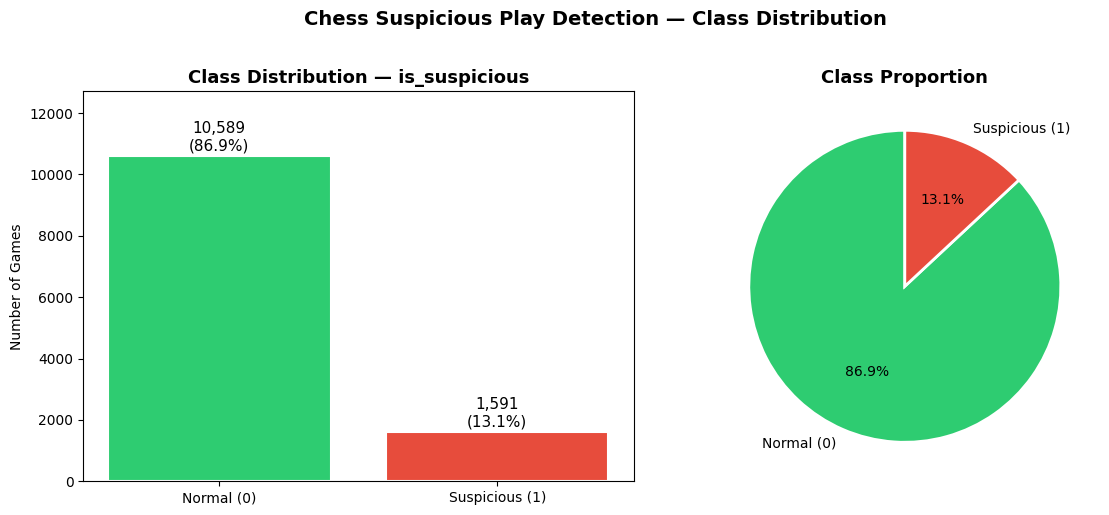

Chart saved to data/class_distribution.png


In [25]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']
labels = ['Normal (0)', 'Suspicious (1)']

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution — is_suspicious', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Games')
for bar, count, pct in zip(bars, counts.values, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_ylim(0, max(counts.values) * 1.2)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Chess Suspicious Play Detection — Class Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to data/class_distribution.png')

---
## 5. Feature Distributions

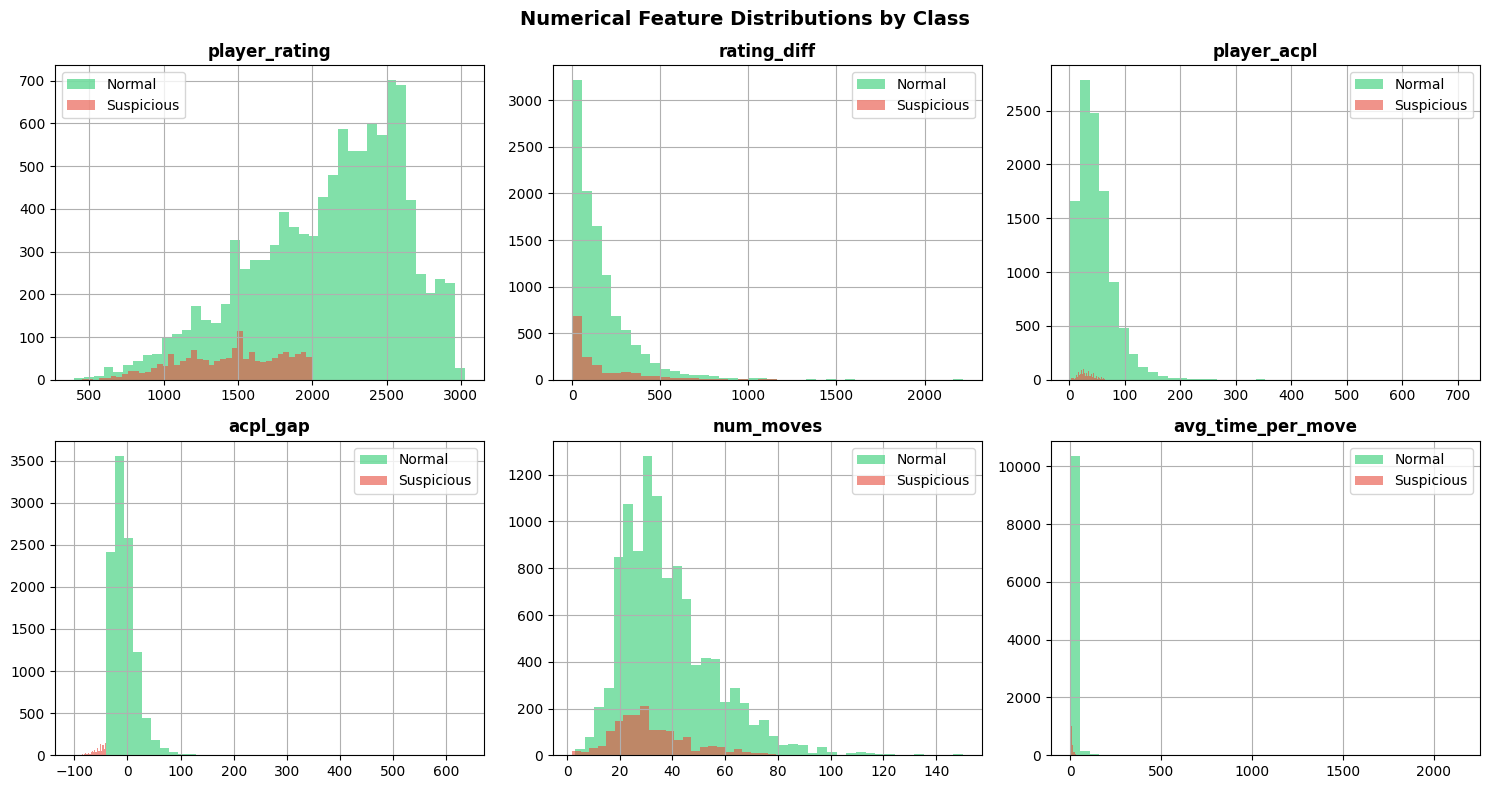

In [26]:
# Numerical features distribution
numerical_cols = ['player_rating', 'rating_diff', 'player_acpl',
                  'acpl_gap', 'num_moves', 'avg_time_per_move']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df[df['is_suspicious']==0][col].hist(ax=axes[i], bins=40, alpha=0.6,
                                          color='#2ecc71', label='Normal')
    df[df['is_suspicious']==1][col].hist(ax=axes[i], bins=40, alpha=0.6,
                                          color='#e74c3c', label='Suspicious')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel('')

plt.suptitle('Numerical Feature Distributions by Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

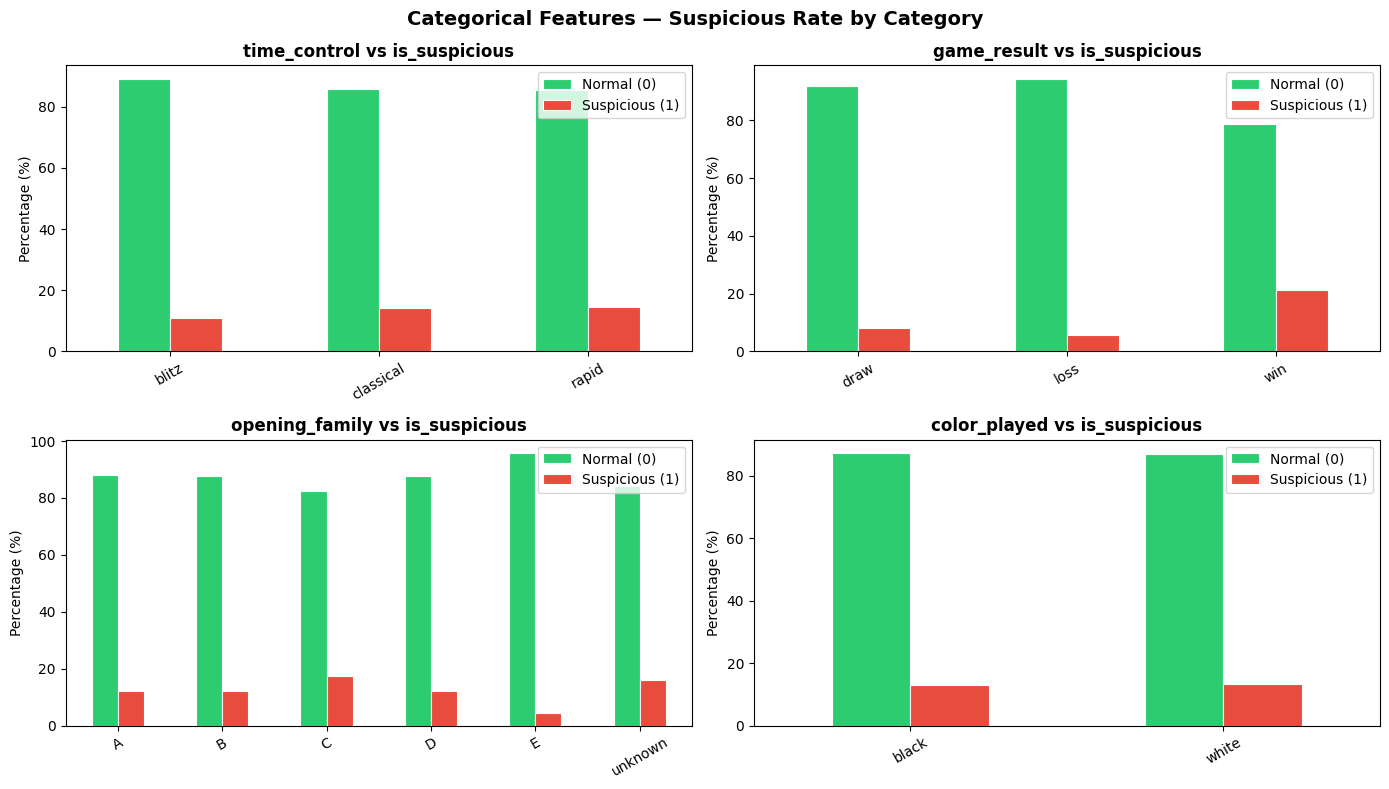

In [27]:
# Categorical features
categorical_cols = ['time_control', 'game_result', 'opening_family', 'color_played']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['is_suspicious'], normalize='index') * 100
    ct.columns = ['Normal (0)', 'Suspicious (1)']
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col} vs is_suspicious', fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend()

plt.suptitle('Categorical Features — Suspicious Rate by Category',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Key Feature: ACPL Gap Analysis

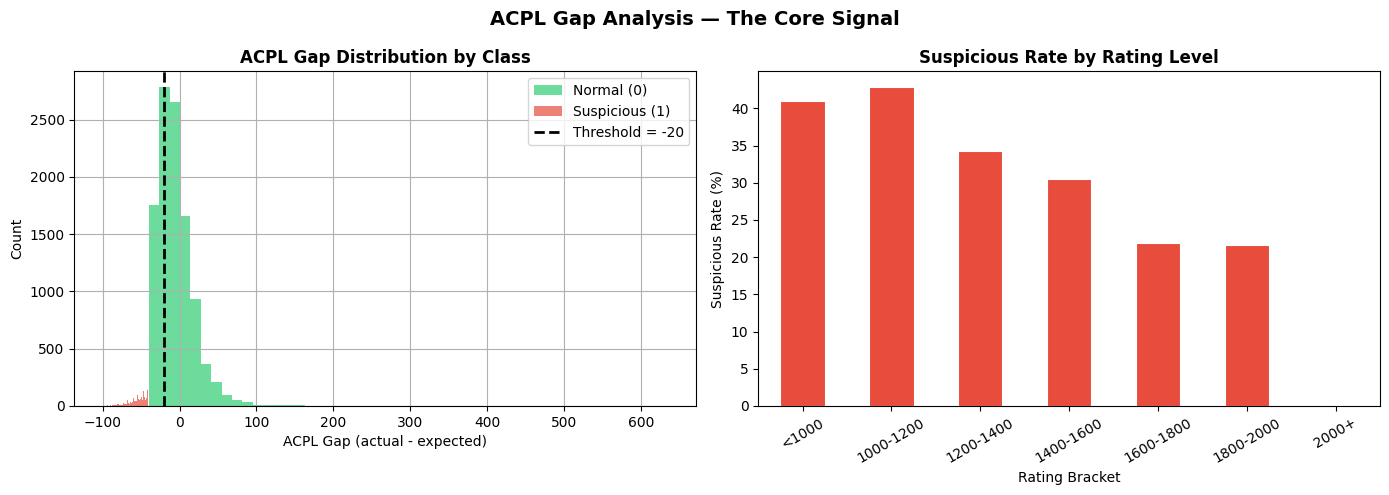

In [28]:
# ACPL gap is our main signal — let's visualize it clearly
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of acpl_gap by class
df[df['is_suspicious']==0]['acpl_gap'].hist(
    ax=axes[0], bins=50, alpha=0.7, color='#2ecc71', label='Normal (0)')
df[df['is_suspicious']==1]['acpl_gap'].hist(
    ax=axes[0], bins=50, alpha=0.7, color='#e74c3c', label='Suspicious (1)')
axes[0].axvline(x=-20, color='black', linestyle='--', linewidth=2, label='Threshold = -20')
axes[0].set_title('ACPL Gap Distribution by Class', fontweight='bold')
axes[0].set_xlabel('ACPL Gap (actual - expected)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Average ACPL gap per rating bucket
df['rating_bucket'] = pd.cut(df['player_rating'],
                               bins=[0,1000,1200,1400,1600,1800,2000,5000],
                               labels=['<1000','1000-1200','1200-1400',
                                       '1400-1600','1600-1800','1800-2000','2000+'])
susp_rate = df.groupby('rating_bucket', observed=True)['is_suspicious'].mean() * 100
susp_rate.plot(kind='bar', ax=axes[1], color='#e74c3c',
               edgecolor='white', linewidth=0.8)
axes[1].set_title('Suspicious Rate by Rating Level', fontweight='bold')
axes[1].set_xlabel('Rating Bracket')
axes[1].set_ylabel('Suspicious Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('ACPL Gap Analysis — The Core Signal',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Correlation with Target

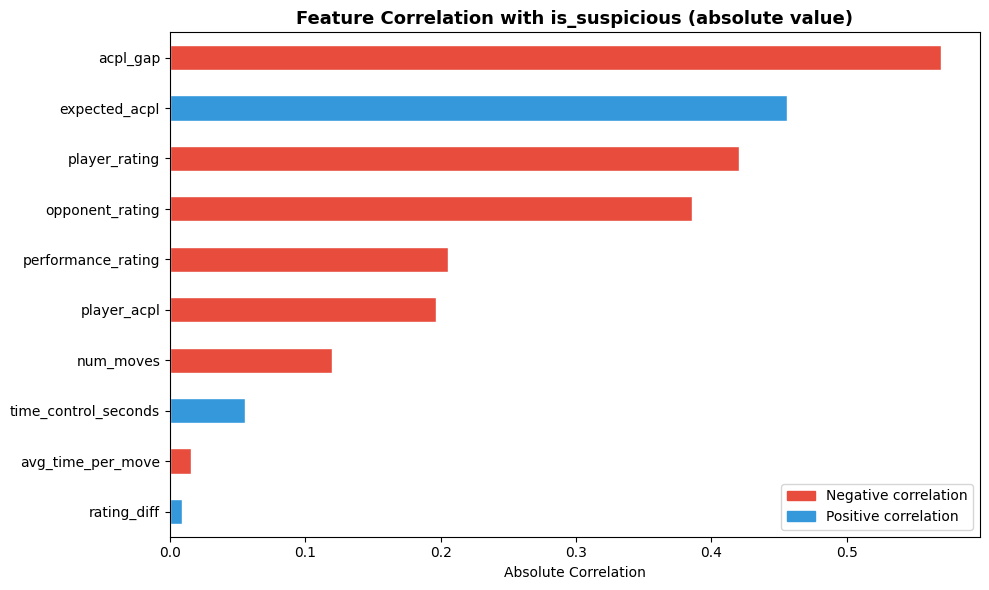


Correlation values with is_suspicious:
expected_acpl           0.456102
time_control_seconds    0.055454
rating_diff             0.009005
avg_time_per_move      -0.015853
num_moves              -0.119725
player_acpl            -0.196484
performance_rating     -0.205468
opponent_rating        -0.385935
player_rating          -0.420683
acpl_gap               -0.569968
Name: is_suspicious, dtype: float64


In [29]:
# Correlation of numerical features with target
numerical_cols = ['player_rating', 'opponent_rating', 'rating_diff',
                  'player_acpl', 'expected_acpl', 'acpl_gap',
                  'num_moves', 'avg_time_per_move', 'performance_rating',
                  'time_control_seconds']

corr = df[numerical_cols + ['is_suspicious']].corr()['is_suspicious'].drop('is_suspicious')
corr_sorted = corr.abs().sort_values(ascending=True)

colors_corr = ['#e74c3c' if corr[c] < 0 else '#3498db' for c in corr_sorted.index]

fig, ax = plt.subplots(figsize=(10, 6))
corr_sorted.plot(kind='barh', ax=ax, color=colors_corr, edgecolor='white')
ax.set_title('Feature Correlation with is_suspicious (absolute value)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Absolute Correlation')

red_patch = mpatches.Patch(color='#e74c3c', label='Negative correlation')
blue_patch = mpatches.Patch(color='#3498db', label='Positive correlation')
ax.legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.show()

print('\nCorrelation values with is_suspicious:')
print(corr.sort_values(ascending=False))

---
## 8. Final Validation Summary

In [30]:
minority_pct = df['is_suspicious'].mean() * 100
num_features = len([c for c in df.columns if c != 'is_suspicious'])
num_numerical = len(df.select_dtypes(include='number').columns) - 1  # exclude target
num_categorical = len(df.select_dtypes(include='object').columns)
missing_total = df.isnull().sum().sum()

print('=' * 55)
print('   PHASE 1 — DATASET VALIDATION SUMMARY')
print('=' * 55)

checks = [
    ('Total rows ≥ 10,000',        len(df) >= 10000,   f'{len(df):,} rows'),
    ('Features ≥ 8',               num_features >= 8,  f'{num_features} features'),
    ('Minority class 5%-25%',      5 <= minority_pct <= 25, f'{minority_pct:.2f}%'),
    ('No missing values',          missing_total == 0, f'{missing_total} missing'),
    ('Has numerical features',     num_numerical > 0,  f'{num_numerical} numerical'),
    ('Has categorical features',   num_categorical > 0, f'{num_categorical} categorical'),
]

all_passed = True
for check, passed, value in checks:
    status = '✅ PASSED' if passed else '❌ FAILED'
    print(f'{status}  |  {check:<30} | {value}')
    if not passed:
        all_passed = False

print('=' * 55)
if all_passed:
    print('🎉 ALL CHECKS PASSED — Dataset is ready for Phase 2!')
else:
    print('⚠️  Some checks failed — review before submission')
print('=' * 55)

   PHASE 1 — DATASET VALIDATION SUMMARY
✅ PASSED  |  Total rows ≥ 10,000            | 12,180 rows
✅ PASSED  |  Features ≥ 8                   | 16 features
✅ PASSED  |  Minority class 5%-25%          | 13.06%
✅ PASSED  |  No missing values              | 0 missing
✅ PASSED  |  Has numerical features         | 10 numerical
✅ PASSED  |  Has categorical features       | 5 categorical
🎉 ALL CHECKS PASSED — Dataset is ready for Phase 2!
